In [23]:
import pandas as pd # for uploading the data
import numpy as np
import re # data cleaning
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

In [24]:
# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon') # (valence Aware Dictionary and Sentiment Reasoner)rule based sentiment analysis
nltk.download('punkt_tab')# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon') # (valence Aware Dictionary and Sentiment Reasoner)rule based sentiment analysis
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [25]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

In [26]:
#Display first few rows
print("Customer Review Dtatset")
print(df.head())

Customer Review Dtatset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [27]:
stop_words = set(stopwords.words('english')) #set to remove the duplicate values in the dataset
def clean_text(text):

   #convert to lowercase
   text = text.lower()

   #remove special characters and punctuation
   text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  #sub---substitue

   #Tokenization
   words = word_tokenize(text)   #word tokenize

   #remove stop words
   words = [word for word in words if word not in stop_words]  #List comprehension
   #LIST COMPREHENSION---IF THE WORD IS THERE OK IF NOT ADD THOSE WORDS IN NEXT STEP

   #Join words again
   cleaned_text = " ".join(words)

   return cleaned_text

   #Apply cleaning function
df['cleaned_Review'] = df['Review'].apply(clean_text)

print("\n Cleaned Review Dataset") #printing
print(df[['Review', 'cleaned_Review']])


 Cleaned Review Dataset
                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                  Amazing product. Worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             cleaned_Review  
0   product quality excellent delivery fast  
1                bad packaging item damaged  
2       customer service helpful responsive  
3     delivery delayed support team respond  
4               amazing product worth money  
5  poor quality product terrible experience  
6              fast shipping good pa

In [28]:
stop_words = set(stopwords.words('english'))
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [29]:
sia = SentimentIntensityAnalyzer()
def analyze_sentiment(review):
    score = sia.polarity_scores(review)
    compound = score['compound']
    if compound >= 0.05:
       return "Positive"
    elif compound <= 0.05:
       return "Negative"
    else:
       return "Neutral"

# Apply sentiment analysis
df['Sentiment'] = df['cleaned_Review'].apply(analyze_sentiment)

print("\nSentiment Analysis")
print(df[['Review', 'cleaned_Review', 'Sentiment']])


Sentiment Analysis
                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                  Amazing product. Worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             cleaned_Review Sentiment  
0   product quality excellent delivery fast  Positive  
1                bad packaging item damaged  Negative  
2       customer service helpful responsive  Positive  
3     delivery delayed support team respond  Positive  
4               amazing product worth money  Positive  
5  poor quality product ter

In [30]:
all_words = " ".join(df['cleaned_Review'])

word_list = all_words.split()

# Count word frequency
word_freq = Counter(word_list)

# Display top 10 keywords
print("\nTop 10 Common Keywords")
print(word_freq.most_common(10))


Top 10 Common Keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [31]:
negative_reviews = df[df['Sentiment'] == 'Negative'] # ROW FILTER

negative_words = " ".join(negative_reviews['cleaned_Review'])

negative_word_list = negative_words.split()

complaint_freq = Counter(negative_word_list)


print("\nTop 10 Negative Keywords")
print(complaint_freq.most_common(10))


Top 10 Negative Keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


In [32]:
sentiment_counts = df['Sentiment'].value_counts() # it will give category count
sentiment_counts

,count
Sentiment,
Positive,6
Negative,4


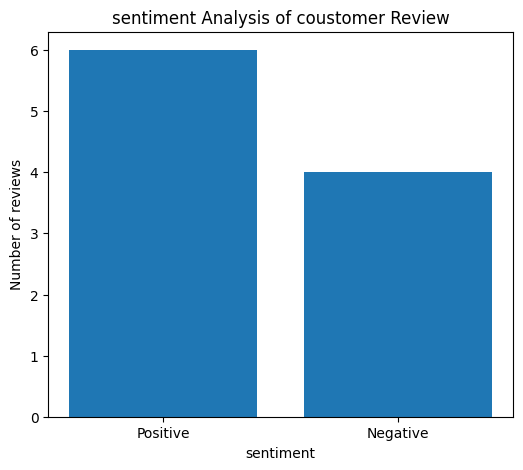

In [33]:
sentiment_counts = df['Sentiment'].value_counts() # it will give category count

plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("sentiment Analysis of coustomer Review")
plt.xlabel("sentiment")
plt.ylabel("Number of reviews")

plt.show()

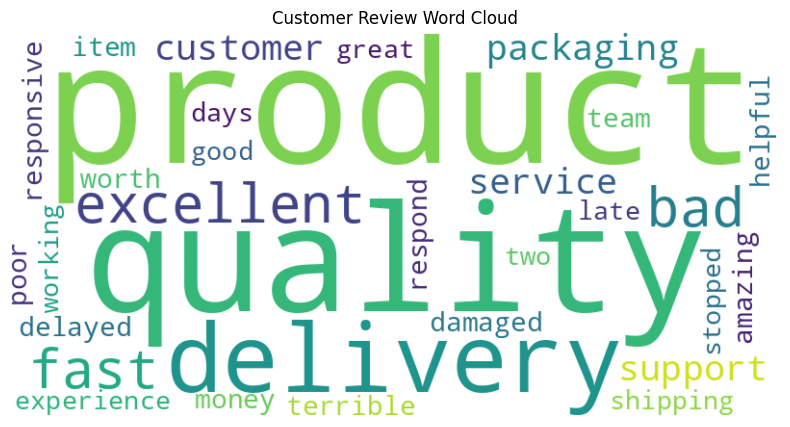

In [34]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Customer Review Word Cloud")
plt.show()


In [35]:
print("\nBusiness Insights")
print("-------------------------------")

positive_count = len(df[df['Sentiment'] == 'Positive'])
negative_count = len(df[df['Sentiment'] == 'Negative'])

print("Total Positive Reviews :", positive_count)
print("Total Negative Reviews :", negative_count)

print("\nCommon Postive Areas:")
print(" Product quality")
print(" Fast delivery")
print(". Good customer service")


print("\nCommon Customer Complaints:")
print(".Delayed delivery")
print(".Damaged products")
print(". Poor support response")
print(". Product malfunction issues ")

print("\nRecommendation:")
print("The company should improve delivery management,")
print("strengthen packaging quality, and enhance customer support response time.")


Business Insights
-------------------------------
Total Positive Reviews : 6
Total Negative Reviews : 4

Common Postive Areas:
 Product quality
 Fast delivery
. Good customer service

Common Customer Complaints:
.Delayed delivery
.Damaged products
. Poor support response
. Product malfunction issues 

Recommendation:
The company should improve delivery management,
strengthen packaging quality, and enhance customer support response time.
